In [ ]:
#!pip install numpy-financial
#!pip install pyxirr

#### -> Import libraries

In [1]:
import pandas as pd
import openpyxl
import warnings
import numpy_financial as npf
import pyxirr 

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

import import_ipynb # Library to call costume functions
import Functions_NPV_py as my_Func

#### -> Specify workbook and Sheet
#### -> Workbook must be on the same folder the JN is.

In [2]:

file_name = "your_workbook.xlsx"
file_name = "00 NPV_py (30 may 26).xlsm"

# Load the workbook and select the sheet
wb = openpyxl.load_workbook(file_name, data_only=True)
sheet = wb["FFSA"]

### Functions

In [3]:
# Function to import range

def Import_Range_from_Excel(range_str,row_i):
    cell_range = sheet[range_str] # Define cell range (e.g., B2:E10)
    
    # Convert range to a pandas DataFrame
    data = []
    for row in cell_range: data.append([cell.value for cell in row])
    
    df = pd.DataFrame(data)
    
    # Optional: Set the first row as the header
    #df.columns = df.iloc[row_i]
    #df = df[1:].reset_index(drop=True)
    
    df.head()
    return df  # Optional




### Import from MS Excel
Production + Capex

In [4]:
# Import Production + CAPEX
Prod_df = Import_Range_from_Excel("E10:AR17",0)
Prod_df

CAPEX_df = Import_Range_from_Excel("E20:AR20",0)*-1000000
CAPEX_df

# Copy the first row
new_row = CAPEX_df.loc[0].copy()

# Append to DataFrame
Prod_df = pd.concat([Prod_df, new_row.to_frame().T], ignore_index=True)
Prod_df.index = ['year', 'Date', 'Days','BOEs','Gas Prod','Gas Sale','Oil','Gasoline','CAPEX']
Prod_df = Prod_df.transpose()

Prod_df['Date'] = pd.to_datetime(Prod_df['Date'], format='%Y %m %d') # Change Date format
Prod_df

,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX
0,1,2026-01-01,365,280.786638,1.529167,1.406833,30.583333,7.645833,-10500000.0
1,2,2027-01-01,365,1652.586207,9,8.28,180,45,0.0
2,3,2028-01-01,366,1495.321837,8.143537,7.492054,162.870735,40.717684,0.0
3,4,2029-01-01,365,1224.265973,6.667364,6.133975,133.34728,33.33682,0.0
4,5,2030-01-01,365,906.95854,4.939305,4.54416,98.786094,24.696524,0.0
5,6,2031-01-01,365,607.95249,3.310915,3.046042,66.218299,16.554575,0.0
6,7,2032-01-01,366,368.741825,2.008171,1.847518,40.163429,10.040857,0.0
7,8,2033-01-01,365,202.369804,1.102108,1.013939,22.042157,5.510539,0.0
8,9,2034-01-01,365,100.493871,0.547291,0.503507,10.945811,2.736453,0.0
9,10,2035-01-01,365,45.154807,0.245914,0.22624,4.91827,1.229568,0.0


### Delete rows without production

In [5]:
# Delete rows without production

# Iterate from last row to first
element = 0
for index, row in Prod_df.iloc[::-1].iterrows():
    print(f"Index: {index}, Value: {row['BOEs']}")
    element = element + 1
    if row['BOEs'] >0:
        LR = index
        break  # Stops the loop completely
print(element)
element = element - 2
# Drops the last 2 rows
Prod_df = Prod_df.iloc[:-element]

Prod_df = Prod_df.fillna(0)

Prod_df

Index: 39, Value: 0
Index: 38, Value: 0
Index: 37, Value: 0
Index: 36, Value: 0
Index: 35, Value: 0
Index: 34, Value: 0
Index: 33, Value: 0
Index: 32, Value: 0
Index: 31, Value: 0
Index: 30, Value: 0
Index: 29, Value: 0
Index: 28, Value: 0
Index: 27, Value: 0
Index: 26, Value: 0
Index: 25, Value: 0
Index: 24, Value: 0
Index: 23, Value: 0
Index: 22, Value: 0
Index: 21, Value: 0
Index: 20, Value: 0
Index: 19, Value: 0
Index: 18, Value: 0
Index: 17, Value: 0
Index: 16, Value: 0
Index: 15, Value: 0
Index: 14, Value: 0
Index: 13, Value: 0
Index: 12, Value: 0
Index: 11, Value: 0
Index: 10, Value: 18.358574451560777
30


C:\Users\Franco\AppData\Local\Temp\ipykernel_29368\4098356205.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Prod_df = Prod_df.fillna(0)


,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX
0,1,2026-01-01,365,280.786638,1.529167,1.406833,30.583333,7.645833,-10500000.0
1,2,2027-01-01,365,1652.586207,9.000000,8.280000,180.000000,45.000000,0.0
2,3,2028-01-01,366,1495.321837,8.143537,7.492054,162.870735,40.717684,0.0
3,4,2029-01-01,365,1224.265973,6.667364,6.133975,133.347280,33.336820,0.0
4,5,2030-01-01,365,906.958540,4.939305,4.544160,98.786094,24.696524,0.0
5,6,2031-01-01,365,607.952490,3.310915,3.046042,66.218299,16.554575,0.0
6,7,2032-01-01,366,368.741825,2.008171,1.847518,40.163429,10.040857,0.0
7,8,2033-01-01,365,202.369804,1.102108,1.013939,22.042157,5.510539,0.0
8,9,2034-01-01,365,100.493871,0.547291,0.503507,10.945811,2.736453,0.0
9,10,2035-01-01,365,45.154807,0.245914,0.226240,4.918270,1.229568,0.0


### Deterministic Evaluation

In [6]:
pd.set_option('display.max_columns', None)  # No column truncation

# -> Import Prices + Tax + Company Shares
BTU_scf = sheet["D29"].value
USD_MMBTU = sheet["D30"].value
Oil_Price = sheet["D32"].value
Gov_tax = sheet["D35"].value
Company_Share = sheet["D36"].value
Headco_cost = sheet["D38"].value*1000000
OPEX = sheet["D37"].value
decommissioning = sheet["D26"].value

my_Func.Print_3_txt('Gas Calorific Value', BTU_scf,' BTU/scf',50, False)
my_Func.Print_3_txt('Gas Price', USD_MMBTU,' USD/MMBTU',50, False)
my_Func.Print_3_txt('Oil Price',Oil_Price,'USD/bbl',50, False)

print('Government Tax = ', Gov_tax)
print('Company Share = ', Company_Share)
print('Annual Headco Cost = ', Headco_cost)
print('OPEX = ', OPEX)
print('Decommissioning/Ab = ', decommissioning)


Cash_Flow_df = pd.DataFrame()
Cash_Flow_df = Prod_df.copy(deep=True)

Cash_Flow_df.loc[:, 'OPEX'] = OPEX  * Cash_Flow_df['BOEs'] * Cash_Flow_df['Days']

Cash_Flow_df.loc[:, 'Ab'] = 0
Cash_Flow_df.iloc[-1, Cash_Flow_df.columns.get_loc('Ab')] = decommissioning

Cash_Flow_df.loc[:, 'Headco Cost'] = -Headco_cost

Cash_Flow_df.loc[:, 'Gas Price'] = BTU_scf * USD_MMBTU
Cash_Flow_df.loc[:, 'Oil Price'] = Oil_Price

Cash_Flow_df.loc[:, 'Gas Rev'] = Cash_Flow_df['Gas Sale'] * Cash_Flow_df['Gas Price']
Cash_Flow_df.loc[:, 'Liquids Rev'] = (Cash_Flow_df['Oil']+Cash_Flow_df['Gasoline']) * Cash_Flow_df['Oil Price']

Cash_Flow_df.loc[:, 'Total Rev USD_day'] = Cash_Flow_df['Gas Rev']+Cash_Flow_df['Liquids Rev']
Cash_Flow_df.loc[:, 'Total Revenue year'] = Cash_Flow_df['Total Rev USD_day'] * Cash_Flow_df['Days']
Cash_Flow_df.loc[:, 'Tax'] = Cash_Flow_df['Total Revenue year'] * -Gov_tax

Cash_Flow_df.loc[:, 'EBITDA'] = Cash_Flow_df['Total Revenue year'] + Cash_Flow_df['OPEX'] + Cash_Flow_df['CAPEX'] 

Cash_Flow_df.loc[:, 'Operating Cash Flow'] = Cash_Flow_df['EBITDA'] + Cash_Flow_df['Tax'] + Cash_Flow_df['Ab'] 

Cash_Flow_df.loc[:, 'Free Cash Flow'] = Cash_Flow_df['Operating Cash Flow'] + Cash_Flow_df['Ab'] 

pd.set_option('display.float_format', '{:.2f}'.format)



discount_rate = 0.10  # 10% cost of capital
cash_flows_L = Cash_Flow_df['Free Cash Flow'].tolist()
#print(cash_flows_L)

# Compute the NPV
# The function automatically treats cash_flows[0] as Year 0 (undiscounted)
npv_result = npf.npv(discount_rate, cash_flows_L)
print('---------------------------')
print(f"Project NPV: ${npv_result:,.2f}") # Display the formatted result

# Calculate IRR
irr = pyxirr.irr(cash_flows_L)
print(f"Internal Rate of Return: {irr:.3f}")

Cash_Flow_df.head(4)
display(Cash_Flow_df)

specific_sum = Cash_Flow_df[['CAPEX', 'Free Cash Flow']].sum()
display(specific_sum)

pd.reset_option('display.max_columns')


Government Tax =  0.5
Company Share =  0.5
Annual Headco Cost =  1000000
OPEX =  -5
Decommissioning/Ab =  2
---------------------------
Project NPV: $16,590,703.03
Internal Rate of Return: 0.767


,year,Date,Days,BOEs,Gas Prod,Gas Sale,Oil,Gasoline,CAPEX,OPEX,Ab,Headco Cost,Gas Price,Oil Price,Gas Rev,Liquids Rev,Total Rev USD_day,Total Revenue year,Tax,EBITDA,Operating Cash Flow,Free Cash Flow
0,1,2026-01-01,365,280.79,1.53,1.41,30.58,7.65,-10500000.00,-512435.61,0,-1000000,5793.60,65,8150.63,2484.90,10635.53,3881966.78,-1940983.39,-7130468.83,-9071452.22,-9071452.22
1,2,2027-01-01,365,1652.59,9.00,8.28,180.00,45.00,0.00,-3015969.83,0,-1000000,5793.60,65,47971.01,14625.00,62596.01,22847542.92,-11423771.46,19831573.09,8407801.63,8407801.63
2,3,2028-01-01,366,1495.32,8.14,7.49,162.87,40.72,0.00,-2736438.96,0,-1000000,5793.60,65,43405.96,13233.25,56639.21,20729950.95,-10364975.48,17993511.99,7628536.52,7628536.52
3,4,2029-01-01,365,1224.27,6.67,6.13,133.35,33.34,0.00,-2234285.40,0,-1000000,5793.60,65,35537.80,10834.47,46372.26,16925876.09,-8462938.05,14691590.69,6228652.65,6228652.65
4,5,2030-01-01,365,906.96,4.94,4.54,98.79,24.70,0.00,-1655199.34,0,-1000000,5793.60,65,26327.05,8026.37,34353.42,12538997.41,-6269498.71,10883798.08,4614299.37,4614299.37
5,6,2031-01-01,365,607.95,3.31,3.05,66.22,16.55,0.00,-1109513.29,0,-1000000,5793.60,65,17647.55,5380.24,23027.78,8405141.32,-4202570.66,7295628.03,3093057.37,3093057.37
6,7,2032-01-01,366,368.74,2.01,1.85,40.16,10.04,0.00,-674797.54,0,-1000000,5793.60,65,10703.78,3263.28,13967.06,5111942.97,-2555971.48,4437145.43,1881173.94,1881173.94
7,8,2033-01-01,365,202.37,1.10,1.01,22.04,5.51,0.00,-369324.89,0,-1000000,5793.60,65,5874.36,1790.93,7665.28,2797828.50,-1398914.25,2428503.61,1029589.36,1029589.36
8,9,2034-01-01,365,100.49,0.55,0.50,10.95,2.74,0.00,-183401.31,0,-1000000,5793.60,65,2917.12,889.35,3806.47,1389360.52,-694680.26,1205959.20,511278.94,511278.94
9,10,2035-01-01,365,45.15,0.25,0.23,4.92,1.23,0.00,-82407.52,0,-1000000,5793.60,65,1310.75,399.61,1710.36,624279.92,-312139.96,541872.40,229732.44,229732.44


CAPEX            -10500000.00
Free Cash Flow    24646332.13
dtype: float64

## Probabilistic Evaluation

Specify distribution type: Normal, Uniform, Constant.

In [7]:
Input_var_dict ={}

var_label, Dist_Type = 'Gas Price','Uniform' 
low, high,val_mean, val_SD, val_Const = 3, 7, 2000, 400, 2500
Input_var_dict['Pr'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

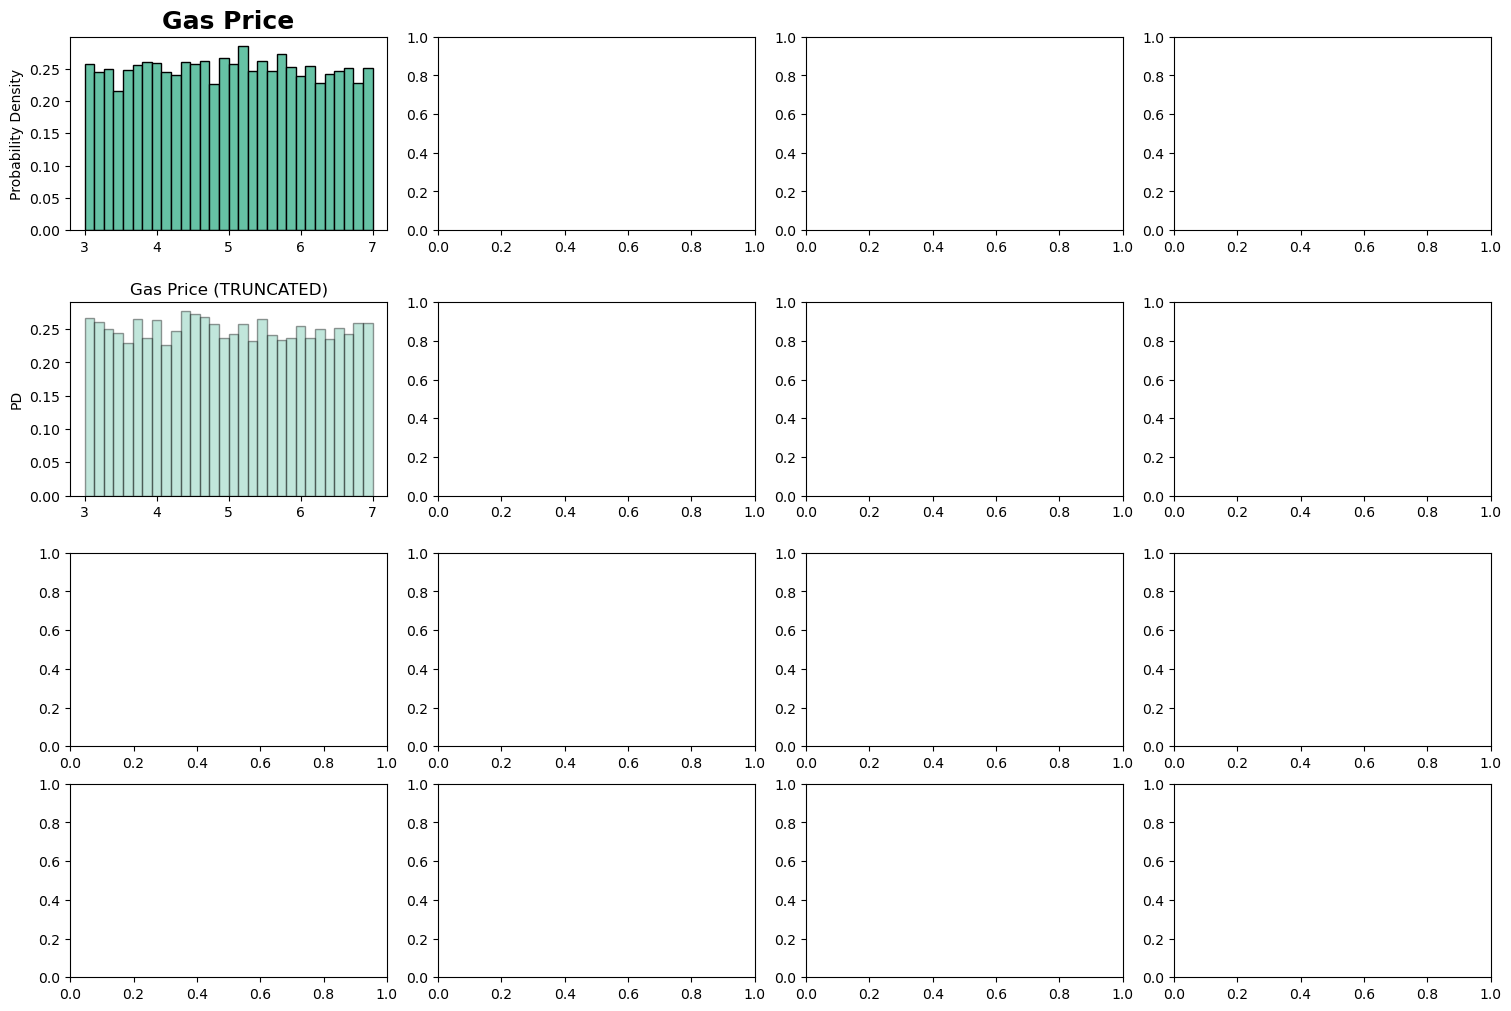

In [8]:
my_Func.Plot_Input_func(Input_var_dict)